In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from Bio.Align import PairwiseAligner, substitution_matrices
from scipy.cluster.hierarchy import fcluster, linkage as sp_linkage
from scipy.spatial.distance import squareform

# Cross-reactivity clustering for PhIP-Seq hit peptides. 

## Pipeline: 
1. seed candidate pairs with reduced-alphabet k-mers (conservative substitution still matches)
2. score each candidate pair with BLOSUM62 Smith-Waterman. 
3. threshold + union-find into clusters

In [2]:
meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')
df = pd.read_csv('long_091826.csv')
hits = pd.read_csv('pep_hits_wo_taxa_to_remove_091826.csv').set_index('peptide')

In [3]:
df.groupby('category')['individual'].nunique()

category
Household contact    277
Lassa survivor       120
US healthy            87
Name: individual, dtype: int64

In [4]:
hits = hits.drop(columns='Unnamed: 0')

In [5]:
sequences = hits['sequence'].to_dict() #this keeps the peptide index
print(len(hits), "hit peptides") 

1287 hit peptides


In [6]:
BLOSUM62 = substitution_matrices.load("BLOSUM62")

def make_aligner():
    aln = PairwiseAligner()
    aln.mode = 'local'
    aln.substitution_matrix = BLOSUM62
    aln.open_gap_score = -10 #same setting as peptide to protein alignment
    aln.extend_gap_score = -0.5
    return aln

def similarity_matrix(sequences, progress_every=200):
    idx     = list(sequences)
    aligner = make_aligner()
    seqs    = [str(sequences[i]).upper() for i in idx]
    selfs   = [aligner.score(s, s) for s in seqs]
    n, mat  = len(idx), np.eye(len(idx))
    for i in range(n):
        for j in range(i + 1, n):
            d = min(selfs[i], selfs[j])
            mat[i, j] = mat[j, i] = aligner.score(seqs[i], seqs[j]) / d if d else 0.0
        if progress_every and (i + 1) % progress_every == 0:
            print(f"  aligned {i+1}/{n} rows")
    return idx, mat

In [7]:
#gives every peptide pair a normalized alignment score

idx, mat = similarity_matrix(sequences)

  aligned 200/1287 rows
  aligned 400/1287 rows
  aligned 600/1287 rows
  aligned 800/1287 rows
  aligned 1000/1287 rows
  aligned 1200/1287 rows


In [8]:
THRESHOLD = 0.5

#hierarchical clustering works with distance, not similarity. So convert to distance by d = 1-s. so if two peptides are identical, 1-1 = 0. distance is 0.
def collapse(idx, mat, threshold=0.5):
    dist = 1.0 - mat #convert similarity to distance
    np.fill_diagonal(dist, 0.0) #force self-distance to zero
    Z    = sp_linkage(squareform(dist, checks=False), method='average') #squareform converts square matrix to condensed form. s-linkage just wants A-B, not the
    #entire matrix. also no diagonals and no duplicates e.t. B-A. checks=False don't spend time checking whether it's a valid symmetry distance metric. 
    #average then performs average-linkage clustering, which is the actual hierarchical clustering. finds closest pair, merges them. Then recalculates distances
    #between clusters using average linkage. Z sotres the entire history of these merges. linkage just keeps going until everything is in a giant cluster.

    flat = fcluster(Z, t=1.0 - threshold, criterion='distance') #cut the hierarchical tree at distance = 0.5. so say I only want to merges that occured at <= 0.5

    labels = {pid: int(c) for pid, c in zip(idx, flat)} #attach cluster numbers to peptide IDs
    n_cl = len(set(flat)) #count number of clusters
    print(f"{len(idx)} peptides -> {n_cl} clusters ({len(idx)/n_cl:.2f}x collapse)") #tells how much redundancy was collapsed
    return labels #return the peptide -> cluster dictionary

#labels gives every peptide a cluster ID
labels = collapse(idx, mat, threshold=THRESHOLD)
hits['cluster'] = hits.index.map(labels)

1287 peptides -> 945 clusters (1.36x collapse)


In [9]:
cl = hits.copy()
cl['cluster'] = cl.index.map(labels)

nsp = cl.groupby('cluster')['species'].nunique() #species per cluster
ngen = cl.groupby('cluster')['genus'].nunique() #genera per cluster

sp_cl = (cl.drop_duplicates(['species','cluster']).assign(specific=lambda t: t.cluster.map(nsp) == 1, 
                                                          cross_genus=lambda t: t.cluster.map(ngen) > 1))

comp = (sp_cl.groupby(['genus','species']).agg(clusters_incl_shared=('cluster','nunique'),
                  clusters_specific=('specific','sum'), 
                  clusters_cross_genus=('cross_genus', 'sum')).reset_index())

n_pep = cl.groupby('species').size().rename('n_peptides')
n_ind = (df[df.reactive].assign(species=lambda t: t.peptide.map(cl['species']))).groupby('species').individual.nunique() #count distinct reactive people per species

sp_tbl = (comp.set_index('species').join([n_pep, n_ind]).reset_index()
          .assign(pct_specific=lambda t: (100*t.clusters_specific/t.clusters_incl_shared).round(1), 
                  pct_cross_genus=lambda t: (100*t.clusters_cross_genus/t.clusters_incl_shared).round(1)))

sp_tbl.sort_values('clusters_incl_shared', ascending=False)

,species,genus,clusters_incl_shared,clusters_specific,clusters_cross_genus,n_peptides,individual,pct_specific,pct_cross_genus
59,Mammarenavirus lassaense,Mammarenavirus,35.0,23.0,2.0,76,393,65.7,5.7
174,Orthonairovirus haemorrhagiae,Orthonairovirus,33.0,28.0,0.0,39,376,84.8,0.0
104,Orthoflavivirus denguei,Orthoflavivirus,25.0,23.0,0.0,32,375,92.0,0.0
310,unidentified Reptarenavirus,Reptarenavirus,13.0,11.0,0.0,14,264,84.6,0.0
52,Mammarenavirus choriomeningitidis,Mammarenavirus,12.0,3.0,2.0,16,338,25.0,16.7
...,...,...,...,...,...,...,...,...,...
26,Hartmanivirus unni,Hartmanivirus,1.0,1.0,0.0,1,30,100.0,0.0
28,Crocidura tanakae henipavirus,Henipavirus,1.0,1.0,0.0,1,43,100.0,0.0
313,Sabavirus americanum,Sabavirus,1.0,1.0,0.0,1,31,100.0,0.0
342,Uukuvirus toyoense,Uukuvirus,1.0,1.0,0.0,1,60,100.0,0.0


In [10]:
react = df[df.reactive].copy() #subset to reactive individual x peptide combinations only
react['cluster'] = react.peptide.map(labels) #add cluster ID

n_total = df.loc[df.cohort == 'SL', 'individual'].nunique()

g = (react.groupby('genus') #groupby genus
          .agg(n_peptides=('peptide','nunique'), #number of unique petides per genus
               n_epitopes=('cluster','nunique'), #number of distinct clusters containing at least one peptide of this genus
               n_individuals=('individual','nunique')) #number of individuals reactive to that genus
          .sort_values('n_epitopes', ascending=False)) #sort by number of epitopes

g['prevalence'] = (100 * g.n_individuals / n_total).round(0) #how many people in % have at least one peptide reactive to this genus
g['pct_collapsed']   = (100 * (1 - g.n_epitopes / g.n_peptides)).round(0) # percent collapsed

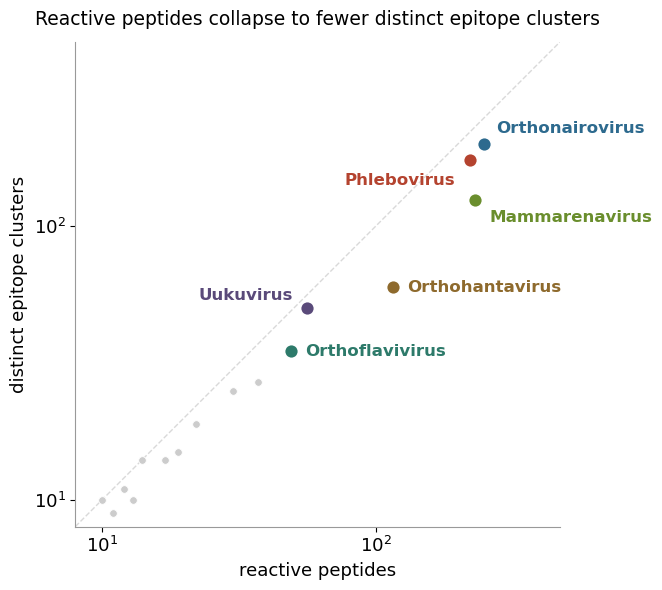

In [23]:
TOPN     = 6
top_gen  = list(g.nlargest(TOPN, 'n_epitopes').index)
PALETTE  = ['#2d6a8e', '#b4432f', '#6a8e2d', '#8e6a2d', '#5a4a7a', '#2d7a6a']
HI       = {gen: PALETTE[i] for i, gen in enumerate(top_gen)}


OFF = {'Orthonairovirus':(9, 8,'left'),  'Phlebovirus':(-11,-18,'right'),
       'Mammarenavirus':(10,-16,'left'), 'Orthohantavirus':(10,-4,'left'),
       'Uukuvirus':(-10,6,'right'),      'Orthoflavivirus':(10,-4,'left'),
       'Reptarenavirus':(-10,-6,'right')}

# --- plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 6))
lim = [8, g.n_peptides.max()*1.9]

sub = g[g.n_peptides >= 8]
for gen, row in sub.iterrows():
    hl = gen in HI
    ax.scatter(row.n_peptides, row.n_epitopes,
               s=100 if hl else 30,
               color=HI.get(gen, '0.80'),
               edgecolor='white', lw=1.2 if hl else .6,
               zorder=4 if hl else 2)

for gen in HI:
    if gen not in sub.index: continue
    row = sub.loc[gen]
    dx, dy, ha = OFF.get(gen, (10, -4, 'left'))
    ax.annotate(gen, (row.n_peptides, row.n_epitopes), fontsize=12,
                color=HI[gen], fontweight='semibold', ha=ha,
                xytext=(dx, dy), textcoords='offset points', zorder=5)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect('equal')

ax.set_xlabel('reactive peptides', fontsize=13)
ax.set_ylabel('distinct epitope clusters', fontsize=13)
ax.set_title('Reactive peptides collapse to fewer distinct epitope clusters', fontsize=13.5, pad=12)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('0.6')

ax.plot(lim, lim, ls='--', color='0.85', lw=1, zorder=1)

ax.tick_params(axis='both', labelsize=13, which='major')
ax.tick_params(which='minor', length=0)

plt.tight_layout()

plt.savefig('peps_vs_epitope_breadth_genera.svg', format='svg')
plt.show()

In [12]:
rows = []
for gen in top_gen:
    v = comp[comp.genus == gen]
    distinct = g.loc[gen, 'n_epitopes']
    top = v.nlargest(1, 'clusters_specific').iloc[0]      # one species
    rows.append({'genus': gen, 'n_species': len(v), 'distinct_clusters': distinct,
                 'top_species': top.species,
                 'pct_incl_shared': round(100*top.clusters_incl_shared/distinct, 1),
                 'pct_specific':    round(100*top.clusters_specific/distinct, 1)})
tt = pd.DataFrame(rows).sort_values('pct_incl_shared')
tt

,genus,n_species,distinct_clusters,top_species,pct_incl_shared,pct_specific
1,Phlebovirus,75,174,Phlebovirus baishanense,3.4,2.9
3,Orthohantavirus,50,60,Orthohantavirus hantanense,8.3,5.0
0,Orthonairovirus,53,199,Orthonairovirus haemorrhagiae,16.6,14.1
4,Uukuvirus,23,50,Uukuvirus uukuniemiense,18.0,18.0
2,Mammarenavirus,49,124,Mammarenavirus lassaense,28.2,18.5
5,Orthoflavivirus,5,35,Orthoflavivirus denguei,71.4,65.7


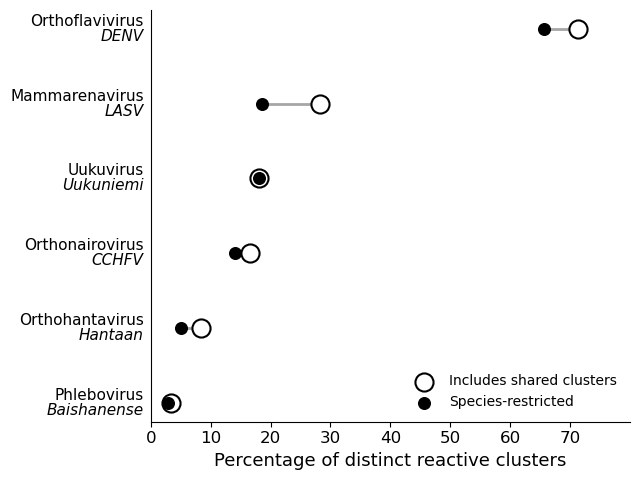

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plot_df = tt.copy()
plot_df = plot_df.sort_values("pct_incl_shared", ascending=True).reset_index(drop=True)

species_short = {
    "Phlebovirus baishanense": "Baishanense",
    "Orthohantavirus hantanense": "Hantaan",
    "Orthonairovirus haemorrhagiae": "CCHFV",
    "Uukuvirus uukuniemiense": "Uukuniemi",
    "Mammarenavirus lassaense": "LASV",
    "Orthoflavivirus denguei": "DENV",
}

plot_df["top_species_short"] = plot_df["top_species"].map(species_short)



fig, ax = plt.subplots(figsize=(6.5, 4.9))

y = np.arange(len(plot_df))

# Connecting lines
for i, row in enumerate(plot_df.itertuples()):
    ax.plot(
        [row.pct_specific, row.pct_incl_shared],
        [i, i],
        color="0.65",
        linewidth=2,
        zorder=1)


# open marker first, larger, lower zorder
ax.scatter(plot_df["pct_incl_shared"], y,
           s=170, facecolor="white", edgecolor="black", linewidth=1.5,
           zorder=2, label="Includes shared clusters")

# filled marker on top, smaller
ax.scatter(plot_df["pct_specific"], y,
           s=70, color="black",
           zorder=3, label="Species-restricted")

ax.set_yticks(y)
ax.set_yticklabels([])

# Manually add genus + species labels
for i, row in enumerate(plot_df.itertuples()):

    # Genus
    ax.text(
        -0.015,
        i + 0.10,
        row.genus,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=11)
    # Species
    ax.text(
        -0.015,
        i - 0.10,
        row.top_species_short,
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=11,
        style="italic")

ax.set_xlabel(
    "Percentage of distinct reactive clusters",
    fontsize=13
)
ax.set_xlim(
    0,
    max(plot_df["pct_incl_shared"].max() * 1.12, 75)
)


ax.tick_params(
    axis="x",
    labelsize=12)

ax.tick_params(
    axis="y",
    length=0)

sns.despine(ax=ax)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right")

plt.tight_layout()

plt.savefig('top_speecies_by_species_restricted_cluster.svg', format='svg')
plt.show()

In [14]:
rows = []
for gen in top_gen:
    v = comp[comp.genus == gen]
    distinct = g.loc[gen, 'n_epitopes']
    top = v.nlargest(1, 'clusters_specific').iloc[0]
    rows.append({
        'Genus': gen,
        'Species represented': len(v),
        'Reactive peptides': int(g.loc[gen, 'n_peptides']),
        'Distinct epitope clusters': int(distinct),
        'Most reactive species': top.species,
        'Clusters containing it': int(top.clusters_incl_shared),
        '% of genus clusters': round(100*top.clusters_incl_shared/distinct, 1),
        'Clusters specific to it': int(top.clusters_specific),
        '% specific': round(100*top.clusters_specific/distinct, 1),
    })

tbl = (pd.DataFrame(rows)
         .sort_values('Distinct epitope clusters', ascending=False)
         .reset_index(drop=True))

tbl.to_csv('table1_genus_species.csv', index=False)
tbl


print(tbl.to_markdown(index=False))                      # Word / Google Docs
#print(tbl.to_latex(index=False, escape=False))           # LaTeX

| Genus           |   Species represented |   Reactive peptides |   Distinct epitope clusters | Most reactive species         |   Clusters containing it |   % of genus clusters |   Clusters specific to it |   % specific |
|:----------------|----------------------:|--------------------:|----------------------------:|:------------------------------|-------------------------:|----------------------:|--------------------------:|-------------:|
| Orthonairovirus |                    53 |                 247 |                         199 | Orthonairovirus haemorrhagiae |                       33 |                  16.6 |                        28 |         14.1 |
| Phlebovirus     |                    75 |                 220 |                         174 | Phlebovirus baishanense       |                        6 |                   3.4 |                         5 |          2.9 |
| Mammarenavirus  |                    49 |                 230 |                         124 | Mammarenavirus l

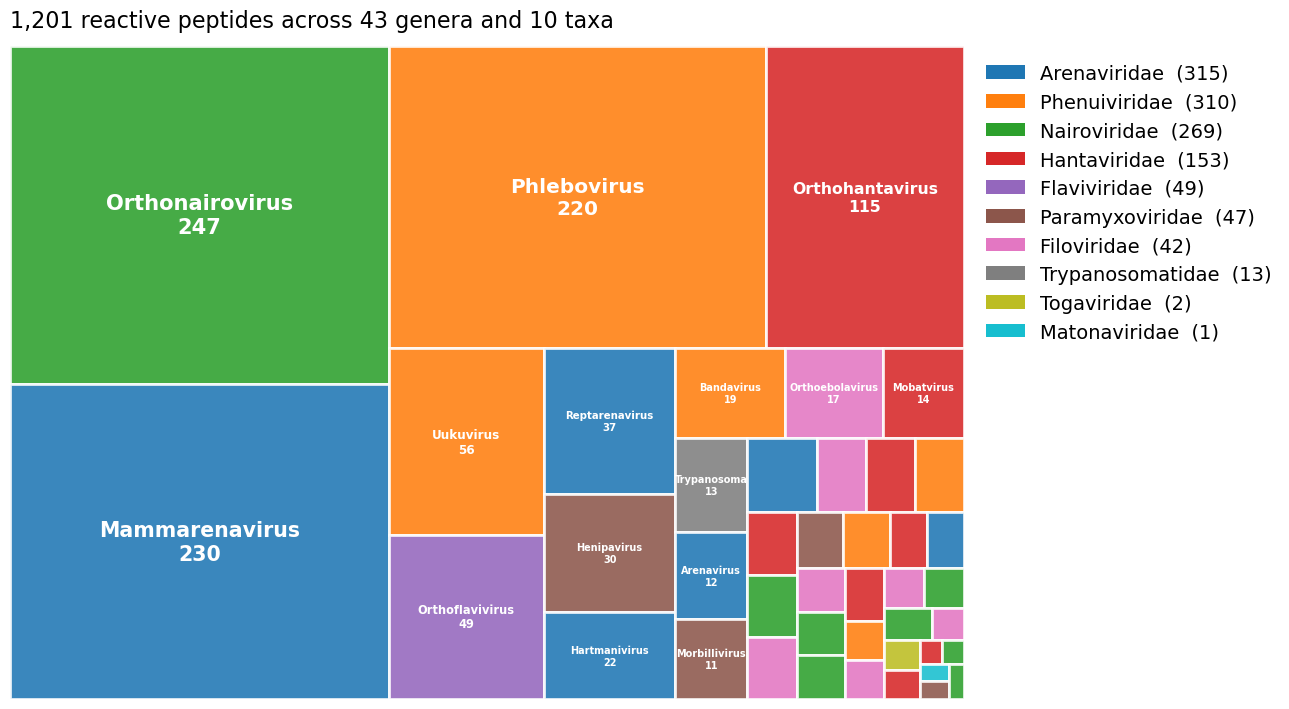

In [15]:
import squarify
from matplotlib.patches import Rectangle

VALUE = 'peptides'        # or 'clusters'

h = hits.copy()
h['cluster'] = h.index.map(labels)
tm = (h.groupby(['family','genus'])
        .agg(peptides=('sequence','size'), clusters=('cluster','nunique'))
        .reset_index()
        .rename(columns={VALUE:'n'})
        .sort_values('n', ascending=False))
tm = tm[tm.n > 0]

fams = tm.groupby('family').n.sum().sort_values(ascending=False)
cmap = plt.get_cmap('tab10')
FCOL = {f: cmap(i % 10) for i, f in enumerate(fams.index)}

fig, ax = plt.subplots(figsize=(13, 7.2))
rects = squarify.squarify(squarify.normalize_sizes(tm.n.to_numpy(float), 100, 62),
                          0, 0, 100, 62)

for r, (_, row) in zip(rects, tm.iterrows()):
    ax.add_patch(Rectangle((r['x'], r['y']), r['dx'], r['dy'],
                           facecolor=FCOL[row.family], edgecolor='white', lw=2, alpha=.88))
    area = r['dx']*r['dy']
    if area > 55:
        ax.text(r['x']+r['dx']/2, r['y']+r['dy']/2, f"{row.genus}\n{row.n}",
                ha='center', va='center', fontsize=np.clip(area**0.38, 7, 17),
                color='white', fontweight='semibold', linespacing=1.25)

ax.set_xlim(0, 100); ax.set_ylim(0, 62); ax.axis('off'); ax.invert_yaxis()
ax.set_title(f'{tm.n.sum():,} reactive peptides across {tm.genus.nunique()} genera '
             f'and {tm.family.nunique()} taxa', fontsize=16, loc='left', pad=14)
ax.legend([Rectangle((0,0),1,1, facecolor=FCOL[f]) for f in fams.index],
          [f'{f}  ({fams[f]})' for f in fams.index],
          frameon=False, fontsize=14, loc='upper left', bbox_to_anchor=(1.005, 1.0))
plt.tight_layout()
plt.savefig('fig_breadth_treemap.pdf', bbox_inches='tight')

### looking at orthonairovirus cross-species clusters

### OLD 

In [16]:
# where the genus signal actually comes from
uuk = hits[hits.genus == 'Uukuvirus'].copy()
uuk['cluster'] = uuk.index.map(labels)
r = df[df.reactive & df.peptide.isin(uuk.index)]
(uuk.join(r.groupby('peptide').individual.nunique().rename('n_ind'))
    .groupby('species').agg(peptides=('sequence','size'), max_ind=('n_ind','max'))
    .sort_values('max_ind', ascending=False).head(10))

,peptides,max_ind
species,,
Uukuvirus dabieshanense,4,105
Uukuvirus qinghaiense,1,95
Uukuvirus tachengense,3,91
Uukuvirus tyulenyense,3,73
Uukuvirus uukuniemiense,10,60
Uukuvirus toyoense,1,60
Uukuvirus okutamaense,2,55
Uukuvirus yongjiaense,1,53
Uukuvirus iftinense,1,41


In [17]:
pid = 'AIW66623.1|glycoprotein|Mammarenavirus_choriomeningitidis|Makokou|Mus_musculus_domesticus|Gabon:_Makokou|06-Jun-2012|S|?|tile_14'
cid = labels[pid]
print('cluster', cid, '— members:')
print(h[h.cluster == cid][['species','protein_std','accession']].to_string())

cluster 99 — members:
                                                                                                                                                                                               species    protein_std    accession
peptide                                                                                                                                                                                                                           
ADD60472.1|precursor|Mammarenavirus_bearense|?|Neotoma_macrotis|USA|Jan-2000|S|AV_B0300052|tile_13                                                                             Mammarenavirus bearense   glycoprotein   ADD60472.1
ADX32840.1|precursor|Menekre_virus|?|Hylomyscus_sp.|Cote_d'Ivoire:_Menekre-_Prefecture_de_Gagnoa|Nov-2005|S|CIV1227|tile_14                                                              Menekre virus   glycoprotein   ADX32840.1
AFU54677.1|precursor|North_American_arenavirus|?|Neotoma_micropus_vouc

## OLD CODE

,genus,n_species,distinct_clusters,top_species,top_pct,pct_species_attributable
0,Orthoflavivirus,5,35,Orthoflavivirus denguei,65.7,91.4
1,Uukuvirus,23,50,Uukuvirus uukuniemiense,18.0,92.0
2,Mammarenavirus,49,124,Mammarenavirus lassaense,18.5,72.6
3,Orthohantavirus,50,60,Orthohantavirus hantanense,5.0,53.3
4,Orthonairovirus,53,199,Orthonairovirus haemorrhagiae,14.1,86.9
5,Phlebovirus,75,174,Phlebovirus limboense,2.9,85.6


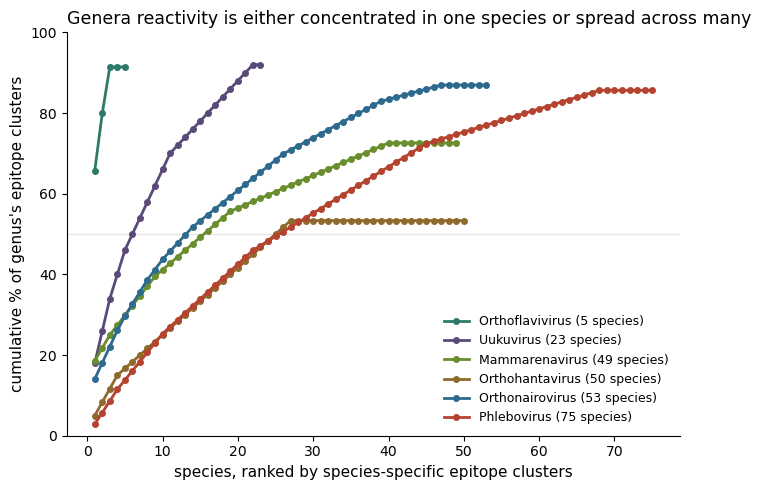

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

order = (comp[comp.genus.isin(top_gen)].groupby('genus').species.nunique()
           .sort_values().index)

rows = []
for gen in order:
    v = (comp[comp.genus == gen]
           .sort_values('clusters_specific', ascending=False))
    distinct = g.loc[gen, 'n_epitopes']
    cum = np.cumsum(v.clusters_specific.to_numpy()) / distinct * 100
    ax.plot(np.arange(1, len(cum)+1), cum, marker='o', ms=4, lw=2,
            color=HI[gen], label=f'{gen} ({len(v)} species)')
    rows.append({'genus': gen, 'n_species': len(v),
                 'distinct_clusters': distinct,
                 'top_species': v.species.iloc[0],
                 'top_pct': round(cum[0], 1),
                 'pct_species_attributable': round(cum[-1], 1)})

ax.axhline(50, color='0.9', lw=1, zorder=0)
ax.set_ylim(0, 100)
ax.set_xlabel('species, ranked by species-specific epitope clusters', fontsize=11)
ax.set_ylabel("cumulative % of genus's epitope clusters", fontsize=11)
ax.set_title('Genera reactivity is either concentrated in one species or spread across many',
             fontsize=12.5, loc='left')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

pd.DataFrame(rows)

In [19]:
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
lasv_cl = set(cl.loc[cl.species == 'Mammarenavirus lassaense', 'cluster'])
shared  = cl[cl.cluster.isin(lasv_cl) & (cl.species != 'Mammarenavirus lassaense')]
print(f"{len(lasv_cl)} LASV clusters, {shared.cluster.nunique()} shared with other species")
print(shared.groupby('species').cluster.nunique().sort_values(ascending=False).head(10))
print(shared.groupby('protein_std').cluster.nunique())

35 LASV clusters, 12 shared with other species
species
Mammarenavirus lunaense              4
Mammarenavirus kwanzaense            3
Mammarenavirus wenzhouense           3
Mammarenavirus caliense              2
Mammarenavirus mopeiaense            2
Mammarenavirus praomyidis            2
Mammarenavirus choriomeningitidis    2
Gbagroube virus                      1
Mammarenavirus loeiense              1
Mammarenavirus kitaleense            1
Name: cluster, dtype: int64
protein_std
glycoprotein     3
nucleoprotein    3
polymerase       7
Name: cluster, dtype: int64


## table for reactive peptides per species and epitopes per responder

In [20]:
per_ind = (react.groupby(['species','individual'])['cluster'].nunique()
                .groupby('species').mean().rename('epitopes_per_responder'))

tab = (react[react.genus.isin(top_gen)]
       .groupby(['genus','species'])
       .agg(n_peptides=('peptide','nunique'),
            n_epitopes=('cluster','nunique'),
            n_individuals=('individual','nunique'))
       .join(per_ind)
       .assign(pct_cohort=lambda t: (100*t.n_individuals/n_total).round(0),
               collapse=lambda t: (100*(1 - t.n_epitopes/t.n_peptides)).round(0),
               epitopes_per_responder=lambda t: t.epitopes_per_responder.round(2))
       .reset_index()
       .sort_values(['genus','n_epitopes'], ascending=[True, False]))

#tab.to_csv('supp_species_table.csv', index=False)
tab.head(20)

,genus,species,n_peptides,n_epitopes,n_individuals,epitopes_per_responder,pct_cohort,collapse
19,Mammarenavirus,Mammarenavirus lassaense,76,35,393,4.91,99.0,54.0
12,Mammarenavirus,Mammarenavirus choriomeningitidis,16,12,338,1.89,85.0,25.0
41,Mammarenavirus,Mammarenavirus wenzhouense,9,9,209,1.41,53.0,0.0
24,Mammarenavirus,Mammarenavirus lunaense,10,8,244,1.69,61.0,20.0
30,Mammarenavirus,Mammarenavirus mopeiaense,9,8,200,1.35,50.0,11.0
42,Mammarenavirus,Mammarenavirus whitewaterense,11,8,225,1.45,57.0,27.0
25,Mammarenavirus,Mammarenavirus lunkense,6,6,171,1.23,43.0,0.0
28,Mammarenavirus,Mammarenavirus marientalense,6,6,237,1.35,60.0,0.0
18,Mammarenavirus,Mammarenavirus kwanzaense,5,5,179,1.21,45.0,0.0
10,Mammarenavirus,Mammarenavirus caliense,4,4,128,1.10,32.0,0.0


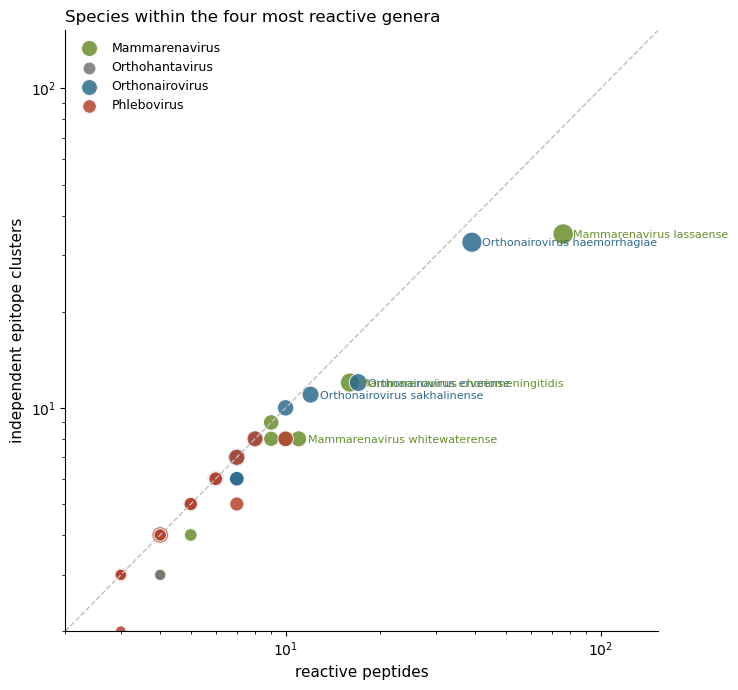

In [21]:
react['species'] = react.peptide.map(hits['species'])
GEN = ['Phlebovirus','Orthonairovirus','Mammarenavirus','Orthohantavirus']

s = (react[react.genus.isin(GEN)]
     .groupby(['genus','species'])
     .agg(n_peptides=('peptide','nunique'), n_epitopes=('cluster','nunique'),
          n_individuals=('individual','nunique')).reset_index())
s['collapse'] = (100*(1 - s.n_epitopes/s.n_peptides)).round(0)
s = s[s.n_peptides >= 3]

GEN_COLOR = {'Phlebovirus':'#b4432f','Orthonairovirus':'#2d6a8e',
             'Mammarenavirus':'#6a8e2d','Orthohantavirus':'0.45'}

fig, ax = plt.subplots(figsize=(7.5, 7))
lim = [2, s.n_peptides.max()*2]
ax.plot(lim, lim, ls='--', color='0.75', lw=1)
for gen, grp in s.groupby('genus'):
    ax.scatter(grp.n_peptides, grp.n_epitopes, s=20 + 2.5*grp.n_individuals/5,
               color=GEN_COLOR[gen], edgecolor='white', lw=.7, alpha=.85, label=gen)

for _, row in s.nlargest(6, 'n_peptides').iterrows():
    ax.annotate(row.species, (row.n_peptides, row.n_epitopes), fontsize=8,
                color=GEN_COLOR[row.genus], xytext=(7, -3), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('reactive peptides', fontsize=11)
ax.set_ylabel('independent epitope clusters', fontsize=11)
ax.set_title('Species within the four most reactive genera', fontsize=12, loc='left')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

In [22]:
for cut in (100, 500, 1000):
    dd = ds[ds.lib_peptides >= cut]
    xx, yy = np.log10(dd.lib_peptides), np.log10(dd.mean_epitopes)
    bb, aa = np.polyfit(xx, yy, 1)
    res = (yy - (aa + bb*xx))
    print(f'cut={cut:5}  n={len(dd):3}  slope={bb:.3f}  ',
          res.reindex(['Mammarenavirus lassaense','Orthonairovirus haemorrhagiae',
                       'Orthoflavivirus denguei']).round(3).to_dict())

NameError: name 'ds' is not defined

In [ ]:
fl = ds.join(hits.drop_duplicates('species').set_index('species')['genus'])
fl[fl.genus == 'Orthoflavivirus'][['lib_peptides','mean_epitopes','n_epitopes']]

In [ ]:
react = df[df.reactive].copy()
react['cluster'] = react.peptide.map(labels)
react['genus']   = react.peptide.map(hits['genus'])

#averages over reactive individuals for that genus
obs   = (react.groupby(['genus','individual'])['cluster'].nunique()
         .groupby('genus').mean().rename('mean_epitopes'))

#average over total cohort so rare genuses will be less weighted
"""n_total = df.loc[df.cohort == 'SL', 'individual'].nunique()
obs = (react.groupby(['genus','individual'])['cluster'].nunique()
            .groupby('genus').sum() / n_total).rename('mean_epitopes')"""


libn  = lib.groupby('genus').size().rename('lib_peptides')
n_ind = react.groupby('genus')['individual'].nunique().rename('n_individuals')

## multiepitope table - using independent epitope clusters as exposure criterion

In [ ]:
def multiepitope_table(df, hits, labels, level='species', reactive_col='reactive'):
    r = df[df[reactive_col]].copy()
    r['cluster'] = r.peptide.map(labels)
    if level not in r.columns:
        r[level] = r.peptide.map(hits[level])
    r = r.dropna(subset=[level, 'cluster'])

    per = (r.groupby([level, 'individual'])['cluster'].nunique()
             .rename('n_epitopes').reset_index())

    return (per.assign(multi=lambda d: d.n_epitopes >= 2)
               .groupby(level)
               .agg(n_individuals=('individual', 'nunique'),
                    n_multi=('multi', 'sum'),
                    max_epitopes=('n_epitopes', 'max'))
               .assign(n_single=lambda d: d.n_individuals - d.n_multi,
                       pct_multi=lambda d: 100 * d.n_multi / d.n_individuals)
               .sort_values('n_multi', ascending=False))


tab = multiepitope_table(df, hits, labels)
tab.head(10)

In [ ]:
def plot_multiepitope(tab, top_n=18, ax=None, min_individuals=1,
                      colors=('#b4432f', '#d9d9d9')):
    t = tab[tab.n_individuals >= min_individuals].head(top_n)[::-1]
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, .42 * len(t) + 1.8))
    ax.barh(t.index, t.n_multi, color=colors[0], label='≥2 independent epitopes',
            edgecolor='white', lw=.7)
    ax.barh(t.index, t.n_single, left=t.n_multi, color=colors[1],
            label='1 epitope only', edgecolor='white', lw=.7)
    for i, (sp, row) in enumerate(t.iterrows()):
        ax.annotate(f'  {row.pct_multi:.0f}%', (row.n_individuals, i),
                    va='center', fontsize=7.5, color='0.35')
    ax.set_xlabel('individuals with reactive peptides', fontsize=9)
    ax.set_xlim(0, t.n_individuals.max() * 1.22)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
    ax.spines[['top','right','left']].set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=8.5)
    ax.set_title('Reactivity to multiple independent epitopes per individual',
                 fontsize=10, loc='left')
    plt.tight_layout()
    return ax


plot_multiepitope(tab, top_n=5)

In [ ]:
if 'genus' not in df.columns:
    df['genus'] = df.peptide.map(hits['genus'])

tab_g = multiepitope_table(df, hits, labels, level='genus')
plot_multiepitope(tab_g, top_n=5)

In [ ]:
size = hits.groupby(hits.index.map(labels)).size()
print(size.value_counts().head())
print(f"{(size==1).mean():.0%} of clusters are singletons")
print(f"{len(hits)} peptides -> {len(size)} clusters")

In [ ]:
fl = hits[hits.genus == 'Orthoflavivirus']
cl = hits.copy(); cl['cluster'] = cl.index.map(labels)
nsp = cl.groupby('cluster')['species'].nunique()

fr = df[df.reactive & df.peptide.isin(fl.index)].copy()
fr['cluster'] = fr.peptide.map(labels)
fr['species'] = fr.peptide.map(hits['species'])
fr['specific'] = fr.cluster.map(nsp) == 1

# per species: how much of its epitope breadth is its own?
print(fr.drop_duplicates(['species','cluster'])
        .groupby('species')['specific'].agg(['sum','count'])
        .assign(pct_specific=lambda t: (100*t['sum']/t['count']).round(0)))

# per individual: does anyone have a DENV-only epitope?
denv = fr[fr.species.str.contains('denguei', na=False)]
print('\nindividuals with >=1 DENV-specific epitope:',
      denv[denv.specific].individual.nunique(), 'of', denv.individual.nunique())

In [ ]:
def plot_species_in_genus(genus, df, hits, labels, top_n=12, min_individuals=20):
    peps = hits[hits.genus == genus].index
    sub  = df[df.peptide.isin(peps)]
    t    = multiepitope_table(sub, hits, labels, level='species')
    t    = t[t.n_individuals >= min_individuals]
    ax   = plot_multiepitope(t, top_n=top_n)
    ax.set_title(f'{genus}: independent epitopes per individual', fontsize=10, loc='left')
    return t

t_mam = plot_species_in_genus('Mammarenavirus', df, hits, labels)

In [ ]:
t_mam = plot_species_in_genus('Orthonairovirus', df, hits, labels)

## Cross-reactivity clusters

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def crossreactive_clusters(hits, labels, species, rank="species"):
    """Clusters containing `species` that also contain >=1 other species."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)
    target_cl = set(h.loc[h[rank] == species, "cluster"])
    sub = h[h.cluster.isin(target_cl)]
    multi = sub.groupby("cluster")[rank].nunique()
    return sub[sub.cluster.isin(multi[multi > 1].index)].sort_values(["cluster", rank])


cc = crossreactive_clusters(hits, labels, "Orthonairovirus haemorrhagiae")
print(cc.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
cc[["cluster", "species", "protein_std", "sequence"]].head(30)

In [ ]:
def plot_cluster(cid, hits, labels, df, value="z_score", rank="species",
                 reactive_col="reactive", max_individuals=400, ax=None):
    h = hits.copy(); h["cluster"] = h.index.map(labels)
    peps = h[h.cluster == cid].sort_values(rank)

    m = (df[df.peptide.isin(peps.index)]
         .pivot_table(index="peptide", columns="individual", values=value))
    m = m.reindex(peps.index)

    hot = df[(df.peptide.isin(peps.index)) & (df[reactive_col])].individual.unique()
    m = m[[c for c in m.columns if c in set(hot)]]
    m = m[m.mean().sort_values(ascending=False).index[:max_individuals]]

    if ax is None:
        _, ax = plt.subplots(figsize=(max(5, .28 * m.shape[1] + 3), .5 * len(m) + 2))
    v = np.nanmax(np.abs(m.to_numpy())) if m.size else 1
    im = ax.imshow(m.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)

    ax.set_yticks(range(len(m)))
    ax.set_yticklabels([peps.loc[p, rank][:34] for p in m.index], fontsize=8)
    ax.set_xticks(range(m.shape[1]))
    ax.set_xticklabels(m.columns, rotation=90, fontsize=6)
    ax.set_title(f"cluster {cid} — {peps[rank].nunique()} species, {len(peps)} peptides",
                 fontsize=9)
    plt.colorbar(im, ax=ax, label=value, fraction=.025)
    return m, peps


cid = cc.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
m, peps = plot_cluster(49, hits, labels, df)
for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
m, peps = plot_cluster(12, hits, labels, df)
for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
lasv = crossreactive_clusters(hits, labels, "Mammarenavirus lassaense")
print(lasv.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
lasv[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = lasv.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
hanta = crossreactive_clusters(hits, labels, 'Orthohantavirus hantanense')
print(hanta.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
hanta[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = hanta.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
hanta = crossreactive_clusters(hits, labels, 'Orthohanairovirus haemorrhagiae')
print(hanta.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
hanta[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = hanta.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(cid, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
cohort_reactivity = hits.groupby('species')['sensitivity'].max()

In [ ]:
hits.loc[hits['species'] == 'Bandavirus dabieense']

In [ ]:
nairo = crossreactive_clusters(hits, labels, 'Nairoviridae sp.')
print(nairo.groupby("cluster")["species"].nunique().sort_values(ascending=False).head(10))
nairo[["cluster", "species", "protein_std", "sequence"]].head(10)

cid = nairo.groupby("cluster")["species"].nunique().idxmax()   # most species-spanning

m, peps = plot_cluster(454, hits, labels, df)
plt.tight_layout()

for p in peps.index:                     # the sequences, for the figure legend
    print(f"{peps.loc[p,'species'][:38]:40} {peps.loc[p,'sequence']:40}  {peps.loc[p, 'protein_std']}")

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def nairo_crossreactivity_figure(
        hits, labels, df,
        target='Orthonairovirus haemorrhagiae',
        family='Nairoviridae',
        proteins=None, cross_only=True,
        reactive_col='reactive', figsize_scale=(0.30, 0.26)):
    h = hits.copy()
    h['cluster'] = h.index.map(labels)
    h = h[h.family == family]
    if proteins is not None:
        h = h[h.protein_std.isin(proteins)]

    react = df[df[reactive_col]].groupby('peptide')['individual'].nunique()
    h['n_ind'] = h.index.map(react).fillna(0)

    tgt_cl = set(h.loc[h.species == target, 'cluster'])
    h = h[h.cluster.isin(tgt_cl)]
    if cross_only:
        multi = h.groupby('cluster')['species'].nunique()
        h = h[h.cluster.isin(multi[multi > 1].index)]
    if h.empty:
        print('no cross-reactive clusters found'); return None, None

    prots = list(h.protein_std.value_counts().index)
    fig, axes = plt.subplots(
        len(prots), 1, squeeze=False,
        figsize=(max(6, figsize_scale[0] * h.cluster.nunique() + 5),
                 sum(figsize_scale[1] * h[h.protein_std == p].species.nunique() + 1.1
                     for p in prots)),
        gridspec_kw={'height_ratios': [h[h.protein_std == p].species.nunique() + 1
                                       for p in prots]})

    vmax = max(1, h.n_ind.max())
    for ax, prot in zip(axes.ravel(), prots):
        sub = h[h.protein_std == prot]
        piv = sub.pivot_table(index='species', columns='cluster',
                              values='n_ind', aggfunc='max')
        rows = ([target] if target in piv.index else []) + \
               list(piv.drop(index=target, errors='ignore')
                       .notna().sum(1).sort_values(ascending=False).index)
        piv = piv.reindex(rows)
        piv = piv[piv.notna().sum(0).sort_values(ascending=False).index]

        im = ax.imshow(piv.to_numpy(), aspect='auto', cmap='viridis',
                       norm=LogNorm(vmin=1, vmax=vmax))
        ax.set_xticks(range(piv.shape[1]))
        ax.set_xticklabels(piv.columns, fontsize=6, rotation=90)
        ax.set_yticks(range(len(piv)))
        ax.set_yticklabels([s[:42] for s in piv.index], fontsize=7)
        if target in piv.index:
            ax.get_yticklabels()[list(piv.index).index(target)].set_fontweight('bold')
            ax.axhline(list(piv.index).index(target) + .5, color='k', lw=.8)
        ax.set_title(f'{prot}  ({piv.shape[1]} epitope clusters)', fontsize=9, loc='left')
        ax.set_xlabel('epitope cluster', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=.015, label='individuals reactive')

    fig.suptitle(f'{family}: epitope clusters shared between {target}\n'
                 f'and other species, by protein', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, .97])
    return fig, h


fig, sub = nairo_crossreactivity_figure(hits, labels, df)

In [ ]:
# only the immunodominant proteins, for a main-text panel
fig, sub = nairo_crossreactivity_figure(hits, labels, df,
                                        proteins=['nucleoprotein','glycoprotein'])


In [ ]:
nairo_crossreactivity_figure(hits, labels, df, target='Mammarenavirus lassaense', family='Arenaviridae')

In [ ]:
nairo_crossreactivity_figure(hits, labels, df, target='Orthohantavirus hantanense', family='Hantaviridae')

In [ ]:
"""Where does reactivity resolve in the taxonomy?

Each epitope cluster is assigned to its lowest common ancestor (LCA) across the
peptides it contains. A cluster spanning several species of one genus resolves
at that genus; a cluster confined to one species resolves at the leaf. Plotting
the tree with nodes sized by resolved clusters shows, in one panel, which
reactivity is genus-generic (cross-reactive) and which is species-specific.
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

LEVELS = ["family", "genus", "species"]


def assign_lca(hits, labels, df=None, levels=LEVELS, reactive_col="reactive"):
    """Per cluster: the deepest taxonomic level shared by all its peptides."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)

    n_ind = None
    if df is not None:
        r = df[df[reactive_col]].copy()
        r["cluster"] = r.peptide.map(labels)
        n_ind = r.groupby("cluster")["individual"].nunique()

    rows = []
    for cid, g in h.groupby("cluster"):
        lca_level, lca_taxon = None, None
        for lvl in levels:                      # shallow -> deep
            if g[lvl].nunique() == 1:
                lca_level, lca_taxon = lvl, g[lvl].iloc[0]
            else:
                break
        rows.append({
            "cluster": cid,
            "lca_level": lca_level or "root",
            "lca_taxon": lca_taxon or "root",
            "n_peptides": len(g),
            "n_species": g["species"].nunique(),
            "n_individuals": int(n_ind.get(cid, 0)) if n_ind is not None else np.nan,
        })
    return pd.DataFrame(rows)


def plot_taxonomy_flow(hits, labels, df=None, levels=LEVELS,
                       min_individuals=1, max_species_per_genus=12,
                       size_scale=55, figsize=None, label_species=True):
    """Taxonomic tree; node area = epitope clusters resolving there."""
    lca = assign_lca(hits, labels, df, levels)
    if min_individuals > 1 and lca.n_individuals.notna().any():
        lca = lca[lca.n_individuals >= min_individuals]

    h = hits.copy(); h["cluster"] = h.index.map(labels)

    # how much resolves at each node
    res = (lca.groupby(["lca_level", "lca_taxon"])
              .agg(n_clusters=("cluster", "size"),
                   n_ind=("n_individuals", "sum")).reset_index())
    weight = {(r.lca_level, r.lca_taxon): r.n_clusters for r in res.itertuples()}
    ind_w  = {(r.lca_level, r.lca_taxon): r.n_ind      for r in res.itertuples()}

    # build the tree from taxa actually present, keep the busiest species
    tax = h[levels].drop_duplicates()
    keep = []
    for gen, sub in tax.groupby("genus"):
        sp_w = {s: weight.get(("species", s), 0) for s in sub.species}
        order = sorted(sp_w, key=lambda s: -sp_w[s])[:max_species_per_genus]
        keep += [(sub.family.iloc[0], gen, s) for s in order]
    tax = pd.DataFrame(keep, columns=levels)

    # layout: leaves evenly spaced, parents at mean of children
    tax = tax.sort_values(levels)
    ypos, y = {}, 0.0
    for sp in tax.species:
        ypos[("species", sp)] = y; y += 1
    for gen, sub in tax.groupby("genus"):
        ypos[("genus", gen)] = np.mean([ypos[("species", s)] for s in sub.species])
    for fam, sub in tax.groupby("family"):
        ypos[("family", fam)] = np.mean([ypos[("genus", g)] for g in sub.genus.unique()])

    X = {"family": 0.0, "genus": 1.0, "species": 2.0}
    n_leaves = sum(1 for k in ypos if k[0] == "species")
    if figsize is None:                      # scale height to the tree
        figsize = (13, max(4.0, 0.34 * n_leaves + 2.2))
    fig, ax = plt.subplots(figsize=figsize)

    for r in tax.itertuples():                       # edges
        ax.plot([X["family"], X["genus"]],
                [ypos[("family", r.family)], ypos[("genus", r.genus)]],
                color="0.8", lw=.9, zorder=1)
        ax.plot([X["genus"], X["species"]],
                [ypos[("genus", r.genus)], ypos[("species", r.species)]],
                color="0.85", lw=.7, zorder=1)

    vmax = max([v for v in ind_w.values() if np.isfinite(v)] + [1])
    for (lvl, taxon), yy in ypos.items():
        w = weight.get((lvl, taxon), 0)
        ind = ind_w.get((lvl, taxon), 0)
        if w == 0:
            ax.scatter(X[lvl], yy, s=8, c="white", edgecolors="0.7",
                       lw=.6, zorder=3)
        else:
            ax.scatter(X[lvl], yy, s=size_scale * w, zorder=3,
                       c=[ind / vmax if np.isfinite(ind) else .5],
                       cmap="viridis", vmin=0, vmax=1,
                       edgecolors="k", linewidths=.5)
            if w >= 3:                       # only label nodes big enough to read
                ax.annotate(f"{int(w)}", (X[lvl], yy), fontsize=6.5, ha="center",
                            va="center", color="w", zorder=4, fontweight="bold")
        if lvl != "species" or label_species:
            dx = 0.012 * np.sqrt(size_scale * max(w, 1)) + 0.05
            txt = f"{taxon[:38]}" + (f"  ({int(w)})" if 0 < w < 3 else "")
            ax.annotate(txt, (X[lvl] + dx, yy), fontsize=7.2,
                        va="center", ha="left", zorder=4)

    for lvl, x in X.items():
        ax.annotate(lvl.upper(), (x, -1.1), fontsize=9, ha="left",
                    fontweight="bold", color="0.35")

    ax.set_xlim(-.25, 3.3); ax.set_ylim(-1.7, max(ypos.values()) + 0.8)
    ax.invert_yaxis(); ax.axis("off")

    counts = lca.lca_level.value_counts()
    sub = " | ".join(f"{k}: {v} clusters" for k, v in counts.items())
    ax.set_title("Where epitope reactivity resolves in the taxonomy\n"
                 "node area = clusters whose lowest common ancestor is that taxon; "
                 "colour = individuals reactive\n" + sub, fontsize=10, loc="left")
    ax.legend(handles=[Line2D([], [], marker="o", ls="", mfc="0.6", mec="k",
                              ms=np.sqrt(size_scale * n) / 2.2,
                              label=f"{n} cluster{'s' if n > 1 else ''}")
                       for n in (1, 5, 20)],
              loc="lower right", frameon=False, fontsize=8, labelspacing=1.6)
    fig.tight_layout()
    return fig, lca


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

LEVELS = ["family", "genus", "species"]

def assign_lca(hits, labels, df=None, levels=LEVELS, reactive_col="reactive"):
    """Per cluster: the deepest taxonomic level shared by all its peptides."""
    h = hits.copy()
    h["cluster"] = h.index.map(labels)

    n_ind = None
    if df is not None:
        r = df[df[reactive_col]].copy()
        r["cluster"] = r.peptide.map(labels)
        n_ind = r.groupby("cluster")["individual"].nunique()

    rows = []
    for cid, g in h.groupby("cluster"):
        lca_level, lca_taxon = None, None
        for lvl in levels:                      # shallow -> deep
            if g[lvl].nunique() == 1:
                lca_level, lca_taxon = lvl, g[lvl].iloc[0]
            else:
                break
        rows.append({
            "cluster": cid,
            "lca_level": lca_level or "root",
            "lca_taxon": lca_taxon or "root",
            "n_peptides": len(g),
            "n_species": g["species"].nunique(),
            "n_individuals": int(n_ind.get(cid, 0)) if n_ind is not None else np.nan,
        })
    return pd.DataFrame(rows)

def plot_resolution_summary(hits, labels, df=None, levels=LEVELS,
                            min_individuals=1, top_n=10, ax=None,
                            colors=("#2d6a8e", "#7fb0cc", "#d9d9d9")):
    lca = assign_lca(hits, labels, df, levels)
    if min_individuals > 1 and lca.n_individuals.notna().any():
        lca = lca[lca.n_individuals >= min_individuals]

    h = hits.copy(); h["cluster"] = h.index.map(labels)
    genus_of = h.groupby("cluster")["genus"].agg(
        lambda s: s.iloc[0] if s.nunique() == 1 else "multi-genus")
    lca["genus"] = lca.cluster.map(genus_of)

    lca["resolution"] = np.where(lca.lca_level == "species", "species-specific",
                         np.where(lca.lca_level == "genus", "shared within genus",
                                  "shared across genera"))

    lca = lca[lca.genus != "multi-genus"]     # after computing, before plotting

    order = lca.genus.value_counts().index[:top_n][::-1]
    cats = ["species-specific", "shared within genus", "shared across genera"]
    tab = (lca[lca.genus.isin(order)]
           .pivot_table(index="genus", columns="resolution", values="cluster",
                        aggfunc="count", fill_value=0)
           .reindex(index=order, columns=cats, fill_value=0))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, .45 * len(tab) + 1.8))
    left = np.zeros(len(tab))
    for cat, c in zip(cats, colors):
        ax.barh(tab.index, tab[cat], left=left, color=c, label=cat,
                edgecolor="white", linewidth=.7)
        left += tab[cat].to_numpy()

    for i, (g, tot) in enumerate(zip(tab.index, left)):
        pct = 100 * tab.loc[g, "species-specific"] / tot if tot else 0
        ax.annotate(f"  {pct:.0f}% specific", (tot, i), va="center",
                    fontsize=7.5, color="0.35")

    ax.set_xlabel("epitope clusters", fontsize=9)
    ax.set_xlim(0, left.max() * 1.28)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=9)
    ax.set_title("Where epitope reactivity resolves", fontsize=10, loc="left")
    plt.tight_layout()
    return ax, lca


ax, lca = plot_resolution_summary(hits, labels, df)

In [ ]:
def inspect_genus(hits, labels, df, genus, level="genus",
                  reactive_col="reactive", top=15):
    """
    Pull apart one genus's shared-epitope signal: which clusters span multiple
    species, which proteins they sit in, and how many individuals per cohort.
    """
    h = hits.copy(); h["cluster"] = h.index.map(labels)
    h = h[h[level] == genus]
    if h.empty:
        print(f"no hits for {genus}"); return None

    size = h.groupby("cluster").size()
    nsp  = h.groupby("cluster")["species"].nunique()
    shared = nsp[nsp > 1].index

    r = df[df[reactive_col] & df.peptide.isin(h.index)].copy()
    r["cluster"] = r.peptide.map(labels)
    ind = r.groupby("cluster")["individual"].nunique()
    coh = (r.drop_duplicates(["cluster", "individual"])
             .groupby(["cluster", "cohort"]).size().unstack(fill_value=0)
           if "cohort" in r.columns else None)

    rows = []
    for cid in shared:
        g = h[h.cluster == cid]
        rec = {"cluster": cid,
               "n_peptides": int(size[cid]),
               "n_species": int(nsp[cid]),
               "n_individuals": int(ind.get(cid, 0)),
               "proteins": ";".join(sorted(set(g.protein_std))),
               "species": ";".join(sorted(set(g.species))[:3])}
        if coh is not None and cid in coh.index:
            for c in coh.columns:
                rec[f"n_{c}"] = int(coh.loc[cid, c])
        rows.append(rec)

    out = (pd.DataFrame(rows).sort_values("n_individuals", ascending=False)
             .reset_index(drop=True))
    print(f"{genus}: {len(size)} clusters, {len(shared)} genus-shared "
          f"({(size==1).sum()} singletons)")
    print(f"  proteins: {dict(h[h.cluster.isin(shared)].protein_std.value_counts().head(4))}")
    if coh is not None:
        tot = r.drop_duplicates(['cluster','individual']).groupby('cohort').individual.nunique()
        print(f"  reactive individuals by cohort: {dict(tot)}")
    return out.head(top)

In [ ]:
oh = inspect_genus(hits, labels, df, 'Orthohantavirus')
oh

In [ ]:
plot_taxonomy_flow(hits, labels, df, min_individuals=3)        # drop singleton-person clusters
plot_taxonomy_flow(hits, labels, df, max_species_per_genus=6)  # trim crowded genera
plot_taxonomy_flow(hits, labels, df, label_species=False)      # dense version

## broad genus -level reactivity 

In [ ]:
def taxon_crossreactivity_figure(
        hits, labels, df, taxon, level='genus', target=None,
        proteins=None, cross_only=True, reactive_col='reactive',
        min_species=2, max_clusters=None, cell=(0.30, 0.26)):
    """
    Cluster x species map for a whole taxon, one panel per protein.

    target=None  -> genus-wide view: every cluster spanning >= min_species.
                    Use when reactivity is spread across species with no single
                    one dominating -- the figure shows whether that apparent
                    breadth collapses onto a few shared epitopes.
    target='...' -> that species is pinned as the top row and only clusters
                    containing it are shown.
    """
    h = hits.copy()
    h['cluster'] = h.index.map(labels)
    h = h[h[level] == taxon]
    if proteins is not None:
        h = h[h.protein_std.isin(proteins)]
    if h.empty:
        print(f'no hits for {taxon}'); return None, None

    react = df[df[reactive_col]].groupby('peptide')['individual'].nunique()
    h['n_ind'] = h.index.map(react).fillna(0)

    if target is not None:
        h = h[h.cluster.isin(set(h.loc[h.species == target, 'cluster']))]
    if cross_only:
        multi = h.groupby('cluster')['species'].nunique()
        h = h[h.cluster.isin(multi[multi >= min_species].index)]
    if h.empty:
        print('no cross-reactive clusters found'); return None, None
    if max_clusters:
        top = (h.groupby('cluster')['species'].nunique()
                .sort_values(ascending=False).index[:max_clusters])
        h = h[h.cluster.isin(top)]

    prots = list(h.protein_std.value_counts().index)
    fig, axes = plt.subplots(
        len(prots), 1, squeeze=False,
        figsize=(max(6, cell[0] * h.cluster.nunique() + 5),
                 sum(cell[1] * h[h.protein_std == p].species.nunique() + 1.2
                     for p in prots)),
        gridspec_kw={'height_ratios': [h[h.protein_std == p].species.nunique() + 1
                                       for p in prots]})

    vmax = max(1, h.n_ind.max())
    for ax, prot in zip(axes.ravel(), prots):
        sub = h[h.protein_std == prot]
        piv = sub.pivot_table(index='species', columns='cluster',
                              values='n_ind', aggfunc='max')
        rows = list(piv.notna().sum(axis=1).sort_values(ascending=False).index)
        if target in piv.index:
            rows = [target] + [r for r in rows if r != target]
        piv = piv.reindex(rows)
        piv = piv[piv.notna().sum(axis=0).sort_values(ascending=False).index]

        im = ax.imshow(piv.to_numpy(), aspect='auto', cmap='viridis',
                       norm=LogNorm(vmin=1, vmax=vmax))
        ax.set_xticks(range(piv.shape[1]))
        ax.set_xticklabels(piv.columns, fontsize=6, rotation=90)
        ax.set_yticks(range(len(piv)))
        ax.set_yticklabels([s[:42] for s in piv.index], fontsize=7)
        if target in piv.index:
            ax.get_yticklabels()[0].set_fontweight('bold')
            ax.axhline(.5, color='k', lw=.8)
        ax.set_title(f'{prot}  —  {piv.shape[1]} epitope clusters span '
                     f'{piv.notna().any(axis=1).sum()} species', fontsize=9, loc='left')
        ax.set_xlabel('epitope cluster', fontsize=8)
        plt.colorbar(im, ax=ax, fraction=.015, label='individuals reactive')

    fig.suptitle(f'{taxon}: shared epitope clusters across species, by protein',
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, .97])
    return fig, h


def breadth_collapse_summary(hits, labels, df, taxon, level='genus',
                             reactive_col='reactive'):
    """
    The number the genus-wide figure is making: apparent species breadth vs
    independent epitope clusters, per individual.
    """
    h = hits.copy(); h['cluster'] = h.index.map(labels)
    h = h[h[level] == taxon]
    r = df[df[reactive_col] & df.peptide.isin(h.index)].copy()
    r['cluster'] = r.peptide.map(labels)
    r['species'] = r.peptide.map(h['species'])

    out = r.groupby('individual').agg(
        n_peptides=('peptide', 'nunique'),
        n_species_apparent=('species', 'nunique'),
        n_epitope_clusters=('cluster', 'nunique'))
    meta = df.drop_duplicates('individual').set_index('individual')
    if 'cohort' in meta.columns:
        out['cohort'] = meta['cohort']
    return out

In [ ]:
# genus-wide: every cluster spanning >=2 Phlebovirus species
fig, sub = taxon_crossreactivity_figure(hits, labels, df, 'Phlebovirus')

# pin one species as the top row (the CCHFV version)
fig, sub = taxon_crossreactivity_figure(hits, labels, df, 'Orthonairovirus',
                                        target='Orthonairovirus haemorrhagiae')

# --------

In [ ]:
def describe_collapse(hits, labels):
    h = hits.copy()
    h['cluster'] = h.index.map(labels) #attach cluster labels
    sizes = h.groupby('cluster').size() #calculate cluster sizes
    rows = []
    for cid, grp in h[h.cluster.isin(sizes[sizes > 1].index)].groupby('cluster'): #ignore clusters where there is only one peptide
        #then for each cluster ID, give me the rows belonging to that cluster at grp.
        n_fam, n_gen, n_sp, n_acc = (grp[c].nunique() for c in ['family','genus','species','accession']) #is calculating grp['family'].nunique() etc.
        # give me column c from the dataframe grp. 
        kind = ('cross_family'   if n_fam > 1 else
                'cross_genus'    if n_gen > 1 else
                'cross_species'  if n_sp  > 1 else
                'within_species' if n_acc > 1 else 'same_protein')
        rows.append({'cluster': cid, 'n_peptides': len(grp), 'kind': kind,
                     'species_list': ';'.join(sorted(set(grp.species))[:4])})
    out = pd.DataFrame(rows)
    if len(out):
        print(out['kind'].value_counts().to_string())
        return out.sort_values('n_peptides', ascending=False).reset_index(drop=True)
    return out

desc = describe_collapse(hits, labels)
desc.head(20)

In [ ]:
TARGET = ['Orthonairovirus', 'Phlebovirus', "Mammarenavirus"]

h = hits.copy()
h['cluster'] = h.index.map(labels)

fams = h.groupby('cluster')['family'].nunique()
gens = h.groupby('cluster')['genus'].nunique()

tgt = h[h.genus.isin(TARGET)].copy()
tgt['n_fam_in_cluster'] = tgt.cluster.map(fams)

tgt['clean_vs_hits'] = tgt.n_fam_in_cluster == 1



In [ ]:
tgt

In [ ]:
def epitope_breadth(df, labels, reactive_col='reactive'): #only keep reactive peptides
    r = df[df[reactive_col]].copy() #only keep reactive peptides
    r['cluster'] = r['peptide'].map(labels) #give each reactive peptide its cluster id
    g = r.groupby('individual') #want to calculate metrics for each person, creates a new dataframe, out
    out = pd.DataFrame({
        'n_reactive_peptides': g['peptide'].nunique(),
        'n_epitope_clusters':  g['cluster'].nunique(),
        'n_species_apparent':  g['species'].nunique(),
    })
    out['inflation'] = out.n_reactive_peptides / out.n_epitope_clusters.replace(0, np.nan) 
    meta_i = df.drop_duplicates('individual').set_index('individual') #get one row of metadata per individual
    for c in ('cohort', 'category'):
        if c in meta_i.columns:
            out[c] = meta_i[c] #adds cohort and category column to out
    return out

breadth = epitope_breadth(df, labels)
print(breadth.groupby('cohort')[['n_reactive_peptides','n_epitope_clusters',
                                 'n_species_apparent','inflation']].mean().round(2))

In [ ]:
breadth

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, col, title in zip(axes, ['n_reactive_peptides','n_epitope_clusters'],
                          ['Raw peptide hits','Epitope clusters']):
    breadth.boxplot(column=col, by='cohort', ax=ax)
    ax.set_title(title); ax.set_xlabel('')
plt.suptitle(''); plt.tight_layout()